# 03_price_model_regime_decomposition

### Research Question:

How much of Alberta electricity price formation can be explained by observable fundamentals (weather, demand, fuel prices), and how does this relationship change when scarcity / stress regimes are removed?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))
from load_data import load_model_data

df = load_model_data()

print(df.shape)
df.head()

(48935, 67)


,timestamp,pool_price,demand,IMPORT_BC,IMPORT_MT,IMPORT_SK,EXPORT_BC,EXPORT_MT,EXPORT_SK,calgary_temperature_2m,...,abs_demand_ramp,net_load,net_load_ramp,abs_net_load_ramp,gen_ramp,abs_gen_ramp,ramp_stress,total_imports,import_dependence,balance_check
0,2020-01-01 00:00:00,30.24,9467,0,80,0,0,0,0,0.55,...,NaN,8588.448551,NaN,NaN,NaN,NaN,NaN,80,0.008450,-2743.531609
1,2020-01-01 01:00:00,29.43,9361,0,125,0,0,0,0,-0.20,...,106.0,8577.784060,-10.664491,10.664491,-127.208351,127.208351,0.001139,125,0.013353,-2719.739960
2,2020-01-01 02:00:00,29.66,9286,0,125,0,0,0,0,-0.50,...,75.0,8565.784713,-11.999348,11.999348,-89.532789,89.532789,0.001292,125,0.013461,-2734.272748
3,2020-01-01 03:00:00,28.19,9209,0,125,0,0,0,0,-1.55,...,77.0,8507.977929,-57.806784,57.806784,-64.027290,64.027290,0.006277,125,0.013574,-2721.300039
4,2020-01-01 04:00:00,31.17,9195,0,125,0,0,0,0,-2.10,...,14.0,8630.764032,122.786104,122.786104,-25.196383,25.196383,0.013354,125,0.013594,-2732.496422


In [3]:
X = df[['demand', 'HDD', 'CDD', 'wind_index',
        'aeco_price_cad_gj', 'hour', 'month']]

y = df['pool_price']

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

r2 = model.score(X_test, y_test)
print(f"R² on test set: {r2:.3f}")

R² on test set: 0.236


In [5]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

print(coef_df)

             feature  coefficient
4  aeco_price_cad_gj    26.734850
2                CDD    23.771184
5               hour     2.129938
1                HDD     2.084465
6              month     1.988091
0             demand     0.008553
3         wind_index   -13.150167


why is cold weather not spiking the price the same way heat does?

def need some gas prices to continue. 

also $24 increase per degree CDD? 
- maybe this happens because its across all years 2020-2025
- 2022 energy crisis period when both temp and price were elevated - hot summer and glocally high gas price means the model is partially attributing gas price effects to temp
- scarcity spike hours where $999 prices coincide with hot afternoonss, which pulls the coefficient up dramatically

in earlier hourly average price charts, the difference between the overnight low of $50 and afternoon peak of $170 was $120. The difference driven by a combination of demand, hour of day, and temperature. $24 actually seems reasonable within that range. 

a mild summer day with lots of wind, high CDD might barely move price, on a hot day with tight supply, the same CDD value could spike price by hundreds of dollars. so an average across 5 years is really not going to tell you about all that. 

but i guess this first round of modelling is going to be crude no matter what. 

Summer peaks in Alberta are often:

* tighter reserve margins
* lower wind coincidence
* maintenance season effects
* gas stress periods
* afternoon demand ramps

Whereas winter:

* Alberta is operationally designed for winter
* more thermal capacity available
* demand is more predictable
* gas supply chain is generally prepared

average winter hour is predictable
hot summer hour often coincides with tight system conditions





linear regression is part of the issue here. 
- assumes straight line relationship between each variable and price
- effect of each variable is contstant regarless of conditions
- variables act independently of eachother
Real prices behave differently:
- temperature effect on price is non-linear (going from 30C to 35C on a tight supply day causes much bigger price move than the same tempearrture change on a slack day)
- wind and gas prices interact (high wind matters more when gas prices ar ehigh because its displacing otherwise expensive generation)

what the value of R^2 actually means:
- 0.1-0.25 --> weather and fuel only (normal for simple models)
- 0.25-0.45 --> adding grid fundamentals (generation mix, imports)
- 0.45-0.65 --> good fundamental model with regime variables
- 0.65-0.8 --> strong model, probably includes non-linear terms
- 0.8+ --> either very sophisticated (maybe overfit)

--> also a 0.35 R^2 model that's right 65% of the time is still valueable if it makes quicker deicisions/ is easier to interpret than a 0.7 R^2 model, depending on the context. 

Takeaways so far:
1. gas prices are the dominant regime setter: AECO has the largest positive coefficient ($26.73/GJ), which confirms alberta is a gas price driven market. When AECO was $6.53/GJ in June 2022, the model predicts pool prices roughly $120MWh hgiher than when AECO was $0.78GJ in June 2024, holding everything else equal. 
2. wind is better at supressing pool price than temperature is at raising it. -13.15 coefficient means each 1m/s increase in wind speed reduces price by $13.15. HDD coefficient is only 2.08 meaning renewable penetration into the grid is already a bigger price moving factor than heating demand. wind sets which marginal generator is selected. so renewables affect price indirectly as well. 
3. CDD is a more powerful price mover than HDD. summer heat spikes price more than an average cold day in the winter does. a heat wave in the summer creates unexpected demand, but a winder demand is usually more predictable. (?)
4. %76 of price variance is still unexplained. alberta pool price is highly volatile. $999 scarcity hours are essentially discrete events driven by coincident failures, not continuous functions of weather and gas prices. 

* at a trading desk you might build a fundamental model to predict the "fair price" value at each hour. comparing those fair values to the actual market values you can trade the spread when the market appears mispriced relative to fundamentals. 

* at AESO the analystical methods overlap, but the goal is using simulations to model forecast for nex-day load and generation.

* at an infastructure fund you might build a long-run price mdoel to forecast average pool prices over 10-20 years. model different stress test scenarios (increased rate of renewable pentration for example) and use that value to determine wind farm or gas peaker revenue. (AESO flexibilty assessment was kind of like this)



What actually is X_train, y_train?
- training set (80%) the model learns from. it finds coefficients that best fit theses rows. 
- test set (20%) the model never sees this during training, after training you ask it to predict prices for these rows and compare to actual prices. this tells you how well the model generales data it hasnt seen. 
- R^2 is the variation in pool price your model explains --> 23.6% explained by weather and gas prices. 

lets say you predicted the average pool price as the real pool price every day. youd be wrong by X amount every day. but then adding in weather, you'll be wrong, but less wrong. R^2 tells us how much less wrong we are. 

R^2 = 1 - (error with you model/error with just guessing the average)

going from 0.185 to 0.236 is a 27% increase for one variable addition.

ChatGPT corrections:

"""Largest coefficient ≠ most important variable

Because coefficients depend on:

* variable scaling
* units
* variance

Example:

* $26/GJ sounds huge
* but AECO itself only varies over a certain range
* demand coefficient is tiny because demand units are huge

So:

coefficient magnitude alone is not importance

A better framing is:

“AECO materially improves explanatory power and appears to anchor broad price regimes.”

That’s stronger analytically."""

"""You wrote:

“76% unexplained”

That sounds bad psychologically.

But in Alberta power markets?

Honestly:

* not shocking at all
* maybe even expected for this model class

Because you are missing:

* outages
* imports
* reserve margins
* transmission constraints
* bidding behavior
* nonlinear thresholds

Those dominate spikes."""



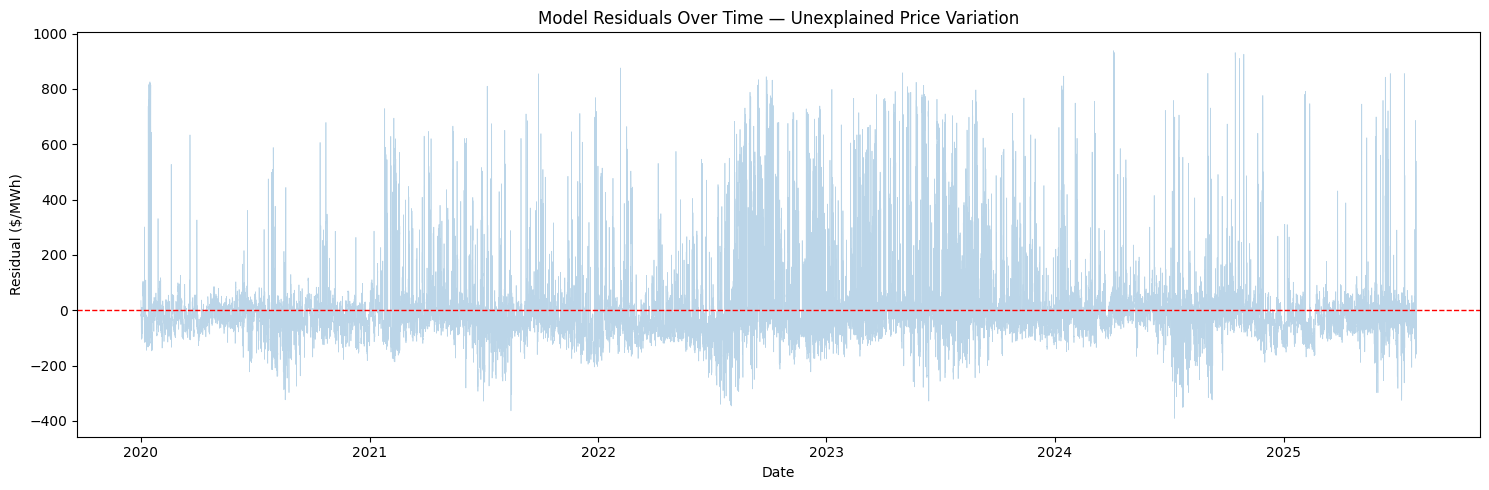

largest unexplained spikes:
                timestamp  pool_price  predicted_price    residual
37315 2024-04-03 20:00:00      999.99        61.782235  938.207765
41988 2024-10-15 13:00:00      978.55        47.284567  931.265433
37350 2024-04-05 07:00:00      999.99        68.799640  931.190360
42319 2024-10-29 08:00:00      999.99        74.431586  925.558414
37351 2024-04-05 08:00:00      999.99        77.817703  922.172297
41992 2024-10-15 17:00:00      998.40        80.750019  917.649981
37352 2024-04-05 09:00:00      999.99        82.419680  917.570320
37360 2024-04-05 17:00:00      999.95        85.232260  914.717740
37353 2024-04-05 10:00:00      999.99        85.636996  914.353004
41989 2024-10-15 14:00:00      961.09        49.827091  911.262909


In [7]:
# Calculate predicted price and residuals for ever row
# residual = actual price minus what model predicts
# positive residual = price was high than model predicts and vice verse
import matplotlib.pyplot as plt

df['predicted_price'] = model.predict(X)
df['residual'] = df['pool_price'] - df['predicted_price']

#plot residuals over time
plt.figure(figsize=(15,5))
plt.plot(df["timestamp"], df["residual"], alpha=0.3, linewidth=0.5)
plt.axhline(y=0, color="red", linewidth=1, linestyle="--")
plt.title("Model Residuals Over Time — Unexplained Price Variation")
plt.xlabel("Date")
plt.ylabel("Residual ($/MWh)")
plt.tight_layout()
plt.show()

# show hours where the model was most strong
print("largest unexplained spikes:")
print(df[['timestamp', 'pool_price', 'predicted_price', 'residual']]
    .sort_values('residual', ascending=False).head(10))


the residual grpah is highly asymmetric. upside is unlimited. price can ump to $999 from a 40,50,60 dollar prediction. but the price floor is 0, so the delta isnt as high there. 

and residuals get higher, and more frequent from 2022 onward. the AESO flexibility assessment predicted this exactly. increased net demand variability and frequent scarcity events as renewables penetration increases. 

all of the top 10 are in 2024 (split either April or October). coal was being retired, scaling renewables. 
- Most hours: price is very low because renewables are suppressing it
- Some hours: price spikes to $999 because when renewables drop suddenly and thermal capacity is tight, there's nothing left to fill the gap

model predicts $60-$85 for those hours because weather and gas prices look normal. But the actual price was $999. That gap — $914-$938 — is entirely explained by grid stress that your model has no variable for.

april and october are called 'shoulder seasons':

April:

Heating demand is dropping so thermal units start going offline for maintenance
Wind is strong and variable in spring
Solar is increasing but not yet reliable
Supply cushion is at its tightest because operators haven't yet prepared for summer peak

October:

Mirror image of April — summer peak has passed, operators are scheduling maintenance
Wind picks up again in fall
Heating season hasn't fully started so thermal units aren't all back online yet
Same supply tightness dynamic

so the understanding of what the model can and cannot do well has grown. generally predictions outside of scarcity events are more accurate. we can explain baseline price levels driven by gas costs, can identify wind suppression effect

but it cannot predict scarcity without grid stress variables
explain shoulder season volatility without supply cushion and outage data
capture the 20244 transition dynamics without generation mix data

This is publishable as a finding:
"The clustering of extreme residuals during shoulder seasons in 2024 suggests that operational grid conditions not captured by weather and fuel variables — potentially including maintenance schedules, reserve tightness, and renewable integration dynamics — played an increasingly important role in Alberta pool price formation.”

but honestly its still hard to say exactly how well the model is working even during normal operation regime conditions

also "maintenance outages, reserve margins, actual renewable ramp event"s are inferred but not actually proven as causes yet. 

same with the coal retirement. definitely a plausible cause, not sure how youd test it exactly. 

regime-aware modeling

Examples:

* classify scarcity vs non-scarcity hours
* separate models by season
* high-wind vs low-wind states
* reserve-tight vs reserve-loose conditions

NEEDS:

grid-state variables

Not more weather.

Specifically:

* outages
* imports/exports
* reserve margin
* generation mix
* renewable share

In [6]:
df['predicted_price'] = model.predict(X)
df['residual'] = df['pool_price'] - df['predicted_price']

In [8]:
fundamental_df = df[df['pool_price'] < 300]

In [12]:
# -----------------------------
# Define features and target
# -----------------------------
X = fundamental_df[
    ['demand', 'HDD', 'CDD', 'wind_index',
     'aeco_price_cad_gj', 'hour', 'month']
]

y = fundamental_df['pool_price']

# -----------------------------
# Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Fit model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# Evaluate
# -----------------------------
r2 = model.score(X_test, y_test)

print(f"R^2 on test set: {r2:.3f}")
print(f"R^2 without AECO: 0.185")
print(f"Improvement: {r2 - 0.185:.3f}")

# -----------------------------
# Coefficients
# -----------------------------
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

print(coef_df)

R^2 on test set: 0.313
R^2 without AECO: 0.185
Improvement: 0.128
             feature  coefficient
4  aeco_price_cad_gj    16.465428
2                CDD     3.424872
5               hour     0.537411
6              month     0.439352
1                HDD     0.257948
0             demand     0.003733
3         wind_index    -5.028717


the R^2 got better, up to 0.313 a 24% increase from 0.236. 

but more noteable the feature coefficients changes drastically. 
wind down from -13 to -5
CDD down i from 23 to 3
gas price down from 26.7 to 16.5

Two different pricing regims in Alberta:

regime A - fundamental regime
price is mostly driven by gas costs, normal demand variation, ordinary weather effects

regime B - scarcity/stress regime
price is mostly driven by reverse tightness, operational constraints, renewable ramps, outages, threshold behaviour (?) generally. but thats not really defined yet in explicit terms. 

winds apparent major importance in the original model was partly inflated by the scarcity dynamics.
- low wind probably coincides with spike events (intuitive)
- spikes massively inflate the coefficient

also the massive decrease in CDD (24 --> 3)
extreme heat itself wasnt the main driver. 
- heat correlated with scarcity conditions. 
- scarcity created giant price movements
when you see a massive change like this with the removal of scarcity hours could you say heat and scarcity events are highly correlated? more so than wind?

also HDD went down (less but from 2 to 0.25), so generally temperature has very little affect on the pricing once scarcity is removed. which maybe makes sense: 
- Alberta's winter demand is expected, system designed for winter conditions, stress occurs during abnormal (unexpected conditions)
could you say across different parts of canada the system is designed around a totally different set of conditions, and youll notice grids are optimized for one thing, and its the other things that acctually cause problems?

also AECO went from 26 --> 16. still the dominant number in the feature list. 

weve now separarted scarcity pricing and fundamental market condition pricing? but i'm sure professional analysts, might break it down into several different layers. but these two are kind of obvious to get out of the way. 

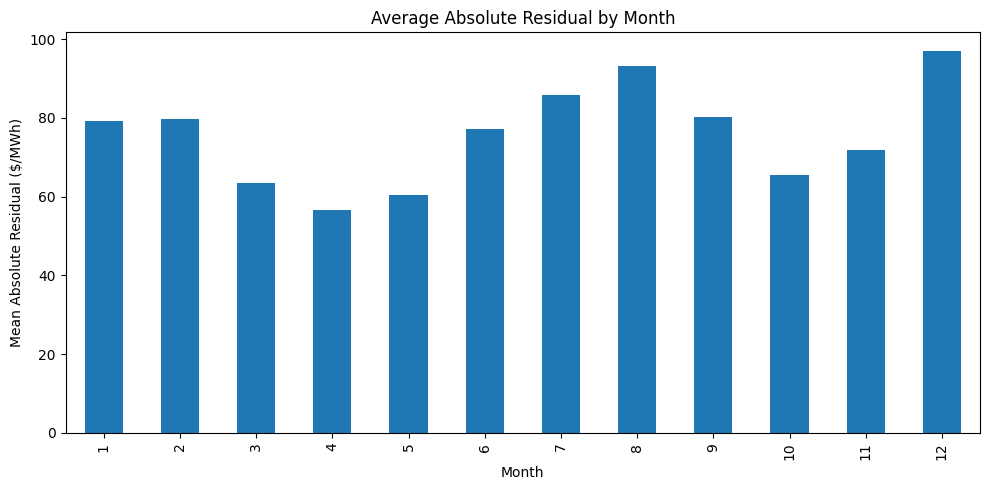

In [14]:
monthly_error = df.groupby('month')['residual'].apply(lambda x: np.mean(np.abs(x)))

plt.figure(figsize=(10,5))
monthly_error.plot(kind='bar')

plt.title('Average Absolute Residual by Month')
plt.ylabel('Mean Absolute Residual ($/MWh)')
plt.xlabel('Month')

plt.tight_layout()
plt.show()

 april and october arent even that high in terms of absoulte residuals. instead, you get 80 for january and february, decrease to a low of 60 in april, increase to a high of 90+ in august, decrease to another low of 60+ in october, and increase again. 

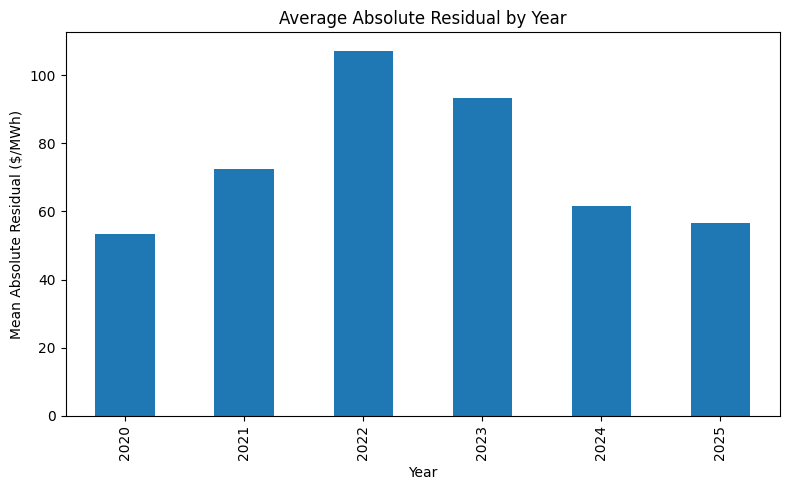

In [15]:
df['year'] = df['timestamp'].dt.year

yearly_error = df.groupby('year')['residual'].apply(lambda x: np.mean(np.abs(x)))

plt.figure(figsize=(8,5))
yearly_error.plot(kind='bar')

plt.title('Average Absolute Residual by Year')
plt.ylabel('Mean Absolute Residual ($/MWh)')
plt.xlabel('Year')

plt.tight_layout()
plt.show()

residuals were exceeding 100 in 2022, below 50 in 2020 and 2025, and barely above 60 in 2024 and 2021, and 202 was around 90

heat-driven peaks
solar intermittency
wildfire/smoke effects sometimes
maintenance overlap
gas tightness
renewable variability
lower reserve margins
(summer dominates residuals)

the most dramatic individual events during the shoulder seasons did not predict consistantly elevated error

fuel regime and macro energy conditions might have been a big contributor here seeing that 2022 had the highest and 2020 and 2025 were significantly lower. 
- global gas crisis?
- ukraine war energy shock
- elevated commodity volatility

(did i accidentally model one of the more unstable periods in recent history?)
- coal retirement alone maybe not be explaining this


Average Absolute Residual by Year and Month:

month      1       2       3      4       5       6       7       8       9   \
year                                                                           
2020   109.67   46.51   44.32  37.18   28.87   39.10   59.01   64.31   43.07   
2021    63.71  123.93   51.27  49.97   56.87   84.87   86.60   61.38   50.85   
2022    68.30   83.67   61.86  60.92   63.68   95.87  115.74  164.24  176.11   
2023    78.12   82.31  121.42  98.67  122.38  142.52  103.42  119.65   72.35   
2024   105.62   56.59   55.99  53.04   31.71   40.61   92.92   56.64   58.97   
2025    50.25   86.68   46.42  39.60   58.63   60.50   56.77     NaN     NaN   

month     10      11      12  
year                          
2020   60.52   46.98   58.19  
2021   52.47   59.31  133.24  
2022   89.40  123.84  182.53  
2023   67.25   63.00   46.73  
2024   57.42   65.65   63.60  
2025     NaN     NaN     NaN  

CSV format:

year,1,2,3,4,5,6,7,8,9,10,11,12
2020,109.67,46.51,

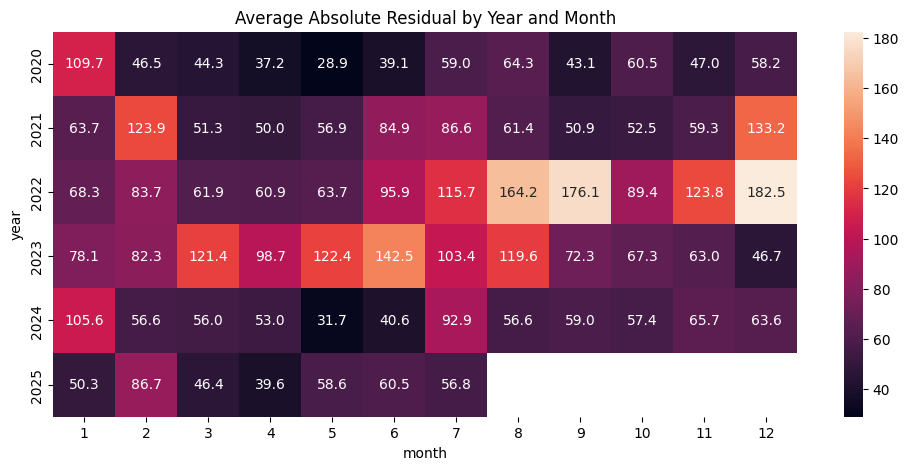

In [16]:
pivot = df.pivot_table(
    values='residual',
    index='year',
    columns='month',
    aggfunc=lambda x: np.mean(np.abs(x))
)

# print readable table
print("\nAverage Absolute Residual by Year and Month:\n")
print(pivot.round(2))

# optional: make it even cleaner for copying
print("\nCSV format:\n")
print(pivot.round(2).to_csv())

# plot heatmap
plt.figure(figsize=(12,5))

import seaborn as sns
sns.heatmap(pivot, annot=True, fmt='.1f')

plt.title('Average Absolute Residual by Year and Month')
plt.show()

by the way, when CDD was a partial cause for the triggering of scarcity conditions, and the earlier model attributed $24/degree value to CDD, that was a confounding factor. CDD wasn't directly causing $500+ prices, but it was correlated with the conditions that caused them. 

also by the way, this separation of scarcity hours from non-scarcity hours was very crude. and id like to learn a more "professional" method -- maybe the separation would depend on data we havent added yet. 

